# Exploration — Périmètre commercial/industriel (DVF géolocalisé 2021-2025)

Objectif : comprendre la structure du périmètre `type_local == 'Local industriel. commercial ou assimilé'` avant de définir ses propres règles de nettoyage — en miroir de `01_exploration_dvf.ipynb`, qui couvre le résidentiel (Maison/Appartement).

Fichier : `data/raw/dvf.csv` — même source que le résidentiel (~3.5 Go, ~20.4 millions de lignes), lue par chunks.

D'après `01_exploration_dvf.ipynb` (§5), ce périmètre représente **3.2% du fichier brut**, soit environ 650 000 lignes attendues — à confirmer ci-dessous.

In [1]:
import pandas as pd
import os

CSV_PATH = r"C:\Users\eree\Documents\projet-immo-france\data\raw\dvf.csv"
CHUNK_SIZE = 500_000  # nombre de lignes lues à la fois
TYPE_LOCAL_CIBLE = "Local industriel. commercial ou assimilé"

# Dossier de cache pour les résultats intermédiaires coûteux à recalculer
# (même logique que dans 01/02 — évite de dépendre de variables du kernel en mémoire)
PROCESSED_DIR = os.path.join(os.path.dirname(os.path.dirname(CSV_PATH)), "processed")
os.makedirs(PROCESSED_DIR, exist_ok=True)
KEEP_MASK_COMMERCIAL_PATH = os.path.join(PROCESSED_DIR, "keep_mask_commercial.npy")
RESUME_COMMERCIAL_PATH = os.path.join(PROCESSED_DIR, "resume_commercial.parquet")

In [2]:
# Thème graphique commun — palette bleu / rouge (immo France), identique à 01/02
COLORS = {
    "bleu_clair": "#dbeafe",
    "bleu_secondaire": "#60a5fa",
    "bleu_primaire": "#2563eb",
    "bleu_marine": "#1e3a8a",
    "rouge_leger": "#fecaca",
    "rouge_modere": "#f87171",
    "rouge_exclusion": "#dc2626",
    "rouge_critique": "#7f1d1d",
}

import matplotlib.pyplot as plt
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

## 1. Aperçu rapide (premières lignes du périmètre commercial/industriel)

In [3]:
apercu_commercial = pd.DataFrame()
N_NEEDED = 10

for chunk in pd.read_csv(CSV_PATH, chunksize=CHUNK_SIZE, low_memory=False):
    match = chunk[chunk["type_local"] == TYPE_LOCAL_CIBLE]
    if len(match) > 0:
        apercu_commercial = pd.concat([apercu_commercial, match])
    if len(apercu_commercial) >= N_NEEDED:
        break

apercu_commercial.head(N_NEEDED)

,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,code_postal,...,type_local,surface_reelle_bati,nombre_pieces_principales,code_nature_culture,nature_culture,code_nature_culture_speciale,nature_culture_speciale,surface_terrain,longitude,latitude
81,2021-36,2021-01-06,1,Vente,158000.0,149.0,E,RUE DES GRANDS CHAMPS,0275,1250.0,...,Local industriel. commercial ou assimilé,63.0,0.0,S,sols,NaN,NaN,199.0,5.420884,46.160378
126,2021-52,2021-01-15,1,Vente,68000.0,118.0,NaN,PL DU FOURNIL,0082,1340.0,...,Local industriel. commercial ou assimilé,100.0,0.0,S,sols,NaN,NaN,227.0,5.176854,46.370102
275,2021-98,2021-01-05,1,Vente terrain à bâtir,74000.0,15.0,B,RUE DES CRETS,1020,1000.0,...,Local industriel. commercial ou assimilé,286.0,0.0,S,sols,NaN,NaN,500.0,5.226414,46.217530
344,2021-114,2021-01-06,1,Vente,70000.0,30.0,NaN,PL MICHEL POISAT,0420,1190.0,...,Local industriel. commercial ou assimilé,180.0,0.0,S,sols,NaN,NaN,341.0,4.940154,46.434924
506,2021-169,2021-01-21,2,Vente,210000.0,30.0,NaN,GR GRANDE RUE,0055,1340.0,...,Local industriel. commercial ou assimilé,106.0,0.0,S,sols,NaN,NaN,169.0,5.128336,46.338128
508,2021-169,2021-01-21,2,Vente,210000.0,30.0,NaN,GR GRANDE RUE,0055,1340.0,...,Local industriel. commercial ou assimilé,91.0,0.0,S,sols,NaN,NaN,169.0,5.128336,46.338128
511,2021-170,2021-01-25,1,Vente,80000.0,431.0,NaN,GR GRANDE RUE,0110,1240.0,...,Local industriel. commercial ou assimilé,160.0,0.0,S,sols,NaN,NaN,251.0,5.194664,46.119996
549,2021-187,2021-01-28,1,Vente,525000.0,14.0,NaN,RUE DES SERVES,0090,1340.0,...,Local industriel. commercial ou assimilé,673.0,0.0,S,sols,NaN,NaN,2617.0,5.119733,46.331903
636,2021-208,2021-01-29,2,Vente,190000.0,2098.0,NaN,RTE DU COLOMBIER,0038,1560.0,...,Local industriel. commercial ou assimilé,233.0,0.0,S,sols,NaN,NaN,500.0,5.087041,46.480667
638,2021-208,2021-01-29,2,Vente,190000.0,2098.0,NaN,RTE DU COLOMBIER,0038,1560.0,...,Local industriel. commercial ou assimilé,144.0,0.0,S,sols,NaN,NaN,500.0,5.087041,46.480667


## 2. Nombre total de lignes du périmètre (comptage par chunk, sans tout charger)

In [4]:
total_commercial = 0
total_brut = 0

for chunk in pd.read_csv(CSV_PATH, chunksize=CHUNK_SIZE, low_memory=False, usecols=["type_local"]):
    total_brut += len(chunk)
    total_commercial += (chunk["type_local"] == TYPE_LOCAL_CIBLE).sum()

print(f"Lignes commercial/industriel : {total_commercial:,}")
print(f"Part du fichier brut : {total_commercial / total_brut * 100:.2f}%")

Lignes commercial/industriel : 650,255
Part du fichier brut : 3.19%


### Interprétation — volumétrie

**Résultat obtenu** : 650 255 lignes commercial/industriel, soit **3.19%** du fichier brut (20 382 915 lignes).

**Interprétation** : quasi identique à l'estimation du notebook 01 (3.2%, ~650K lignes) — écart de
0.01 point, négligeable. Confirme que ce périmètre est stable et bien identifié par le simple filtre
`type_local == 'Local industriel. commercial ou assimilé'`, sans besoin d'ajustement.

## 3. Valeurs manquantes par colonne (sur ce périmètre uniquement)

In [5]:
missing_commercial = None
n_rows_commercial = 0

for chunk in pd.read_csv(CSV_PATH, chunksize=CHUNK_SIZE, low_memory=False):
    sub = chunk[chunk["type_local"] == TYPE_LOCAL_CIBLE]
    n_rows_commercial += len(sub)
    na_counts = sub.isna().sum()
    missing_commercial = na_counts if missing_commercial is None else missing_commercial.add(na_counts, fill_value=0)

(missing_commercial / n_rows_commercial * 100).sort_values(ascending=False)

ancien_id_parcelle              100.000000
numero_volume                   100.000000
ancien_code_commune              99.997539
ancien_nom_commune               99.997539
lot5_surface_carrez              99.788852
lot4_surface_carrez              99.623379
lot3_surface_carrez              99.211079
nature_culture_speciale          98.697127
code_nature_culture_speciale     98.697127
lot5_numero                      98.137039
lot2_surface_carrez              97.483756
lot4_numero                      97.076378
lot3_numero                      94.924914
adresse_suffixe                  91.556236
lot2_numero                      88.744262
lot1_surface_carrez              85.014956
lot1_numero                      55.641095
surface_terrain                  44.942984
nature_culture                   44.940216
code_nature_culture              44.940216
surface_reelle_bati               5.540749
adresse_numero                    3.268256
latitude                          2.763377
longitude  

### Interprétation — valeurs manquantes

**Résultat obtenu** (colonnes les plus significatives, % manquant sur les 650 255 lignes) :

| Colonne | % manquant |
|---|---|
| surface_terrain / nature_culture | 44.94% |
| surface_reelle_bati | 5.54% |
| adresse_numero | 3.27% |
| latitude / longitude | 2.76% |
| nombre_pieces_principales | 1.79% |
| valeur_fonciere | 1.38% |
| lot1_numero à lot5_numero, lot*_surface_carrez | 55% à 100% |
| ancien_id_parcelle, numero_volume | 100% |

**Interprétation** :
- `surface_reelle_bati` est nettement **moins fiable qu'en résidentiel** (5.54% manquant ici contre
  0.01% pour Maison/Appartement, notebook 02 §Cohérence surface/pièces). Contrairement au résidentiel
  où aucun retraitement n'était nécessaire, ici une vraie règle d'exclusion (ou a minima de
  signalement) sera indispensable.
- `nombre_pieces_principales` est étonnamment bien renseigné (1.79% manquant seulement) — mais cette
  bonne complétude ne dit rien de sa **pertinence sémantique** : le nombre de "pièces principales"
  d'un entrepôt ou d'un local commercial n'a pas le même sens que pour un logement. Contrairement au
  résidentiel où c'était un signal de qualité central (anomalie >20 pièces), cette colonne est
  probablement à écarter des règles de nettoyage pour ce périmètre plutôt qu'à corriger.
- `surface_terrain` / `nature_culture` manquants à 44.94% (valeur identique aux deux colonnes →
  cohérent, attributs liés) : environ un local commercial sur deux n'a pas de terrain distinct
  rattaché (ex : local en pied d'immeuble, lot de bureaux) — attendu, ne nécessite pas de règle
  corrective, juste un signal descriptif possible en Phase 2.
- Les colonnes `lot2_numero` à `lot5_numero` et leurs surfaces Carrez associées sont massivement
  vides (85% à 100%) — cohérent avec la répartition de `nombre_lots` (§5, ci-dessous) : la grande
  majorité des transactions ne portent que sur 0 ou 1 lot.

## 4. Répartition de `nature_mutation` (sur ce périmètre)

In [6]:
nature_mutation_commercial = None

for chunk in pd.read_csv(CSV_PATH, chunksize=CHUNK_SIZE, low_memory=False, usecols=["type_local", "nature_mutation"]):
    sub = chunk[chunk["type_local"] == TYPE_LOCAL_CIBLE]
    counts = sub["nature_mutation"].value_counts(dropna=False)
    nature_mutation_commercial = counts if nature_mutation_commercial is None else nature_mutation_commercial.add(counts, fill_value=0)

nature_mutation_commercial.sort_values(ascending=False)

nature_mutation
Vente                                 621138.0
Vente en l'état futur d'achèvement     22307.0
Adjudication                            2874.0
Echange                                 2431.0
Vente terrain à bâtir                   1169.0
Expropriation                            336.0
Name: count, dtype: float64

### Interprétation — nature_mutation

**Résultat obtenu** (650 255 lignes) :

| nature_mutation | Volume | % |
|---|---|---|
| Vente | 621 138 | 95.52% |
| Vente en l'état futur d'achèvement (VEFA) | 22 307 | 3.43% |
| Adjudication | 2 874 | 0.44% |
| Echange | 2 431 | 0.37% |
| Vente terrain à bâtir | 1 169 | 0.18% |
| Expropriation | 336 | 0.05% |

**Interprétation** : la part de VEFA (3.43%) est nettement plus élevée que sur le périmètre
résidentiel nettoyé (1.92%, notebook 02 §VEFA) — cohérent avec le fait que les grandes opérations
commerciales neuves (locaux de centre commercial, plateaux de bureaux, entrepôts logistiques neufs)
sont fréquemment vendues sur plan à des investisseurs institutionnels, plus que les logements
individuels. Adjudication/Echange/Expropriation restent marginaux (<1% cumulé), comme en résidentiel.

**Règle retenue (même logique que le résidentiel)** : filtre d'entrée
`nature_mutation IN ('Vente', 'Vente en l'état futur d'achèvement')`, avec `est_vefa` comme variable
d'analyse plutôt que critère d'exclusion — ce qui représenterait 643 445 lignes (98.95% du périmètre
commercial/industriel).

## 5. Répartition de `nombre_lots` — signal de copropriété/vente en bloc commerciale ?

Sur le résidentiel (notebook 01, §5bis), `nombre_lots` a servi de premier signal pour repérer les
ventes en bloc, confirmé ensuite par le hashing sur `id_mutation` (notebook 02). Pour le commercial
(immeubles de bureaux, centres commerciaux), ce signal est probablement encore plus déterminant —
à vérifier ici.

In [7]:
nombre_lots_commercial = None

for chunk in pd.read_csv(CSV_PATH, chunksize=CHUNK_SIZE, low_memory=False, usecols=["type_local", "nombre_lots"]):
    sub = chunk[chunk["type_local"] == TYPE_LOCAL_CIBLE]
    counts = sub["nombre_lots"].value_counts(dropna=False)
    nombre_lots_commercial = counts if nombre_lots_commercial is None else nombre_lots_commercial.add(counts, fill_value=0)

nombre_lots_commercial.sort_index()

nombre_lots
0      361809.0
1      215255.0
2       40190.0
3       13990.0
4        6897.0
         ...   
161         2.0
175         1.0
188         1.0
190         1.0
236         1.0
Name: count, Length: 123, dtype: float64

### Interprétation — nombre_lots

**Résultat obtenu** :

| nombre_lots | Volume | % |
|---|---|---|
| 0 | 361 809 | 55.65% |
| 1 | 215 255 | 33.10% |
| 2 | 40 190 | 6.18% |
| 3 | 13 990 | 2.15% |
| 4 | 6 897 | 1.06% |
| 5+ | 12 114 | 1.86% |
| (max observé) | 236 | — |

**Interprétation** : hypothèse de départ **infirmée**. Contrairement à l'intuition ("le commercial
devrait avoir plus de multi-lots que le résidentiel"), **88.75%** des transactions commerciales/
industrielles portent sur 0 ou 1 lot — un profil très proche de biens individuels, pas de
copropriétés étendues. La queue à 5+ lots (1.86%, jusqu'à 236 lots dans les cas extrêmes) existe bien
mais reste minoritaire, comme sur le résidentiel.

**Conséquence pratique** : `nombre_lots` seul n'est **pas** un signal suffisant pour détecter une
vente en bloc sur ce périmètre — exactement la même limite que sur le résidentiel, où le vrai signal
retenu était `id_mutation` multi-lignes + `valeur_fonciere` identique (notebook 02, Vérification
2bis/5), pas `nombre_lots` en tant que tel.

**Recommandation** : réappliquer directement cette méthodologie (nb_lignes par `id_mutation` + test
d'égalité de `valeur_fonciere`) sur ce périmètre, plutôt que de construire une nouvelle règle basée
sur `nombre_lots`.

## 6. Distribution de `valeur_fonciere` (ventes uniquement, ce périmètre)

In [8]:
vf_commercial = pd.Series(dtype="float64")

for chunk in pd.read_csv(CSV_PATH, chunksize=CHUNK_SIZE, low_memory=False,
                          usecols=["type_local", "nature_mutation", "valeur_fonciere"]):
    sub = chunk[(chunk["type_local"] == TYPE_LOCAL_CIBLE) & (chunk["nature_mutation"] == "Vente")]
    vf_commercial = pd.concat([vf_commercial, sub["valeur_fonciere"].dropna()])

vf_commercial.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99, 0.999])

count    6.124750e+05
mean     2.005659e+06
std      3.343518e+07
min      1.500000e-01
1%       1.000000e+00
25%      1.180000e+05
50%      2.600000e+05
75%      7.050000e+05
99%      3.124620e+07
99.9%    1.572000e+08
max      1.415000e+10
dtype: float64

### Interprétation — valeur_fonciere

**Résultat obtenu** (612 475 lignes Vente, valeur_fonciere renseignée) :

| Percentile | Valeur |
|---|---|
| Min | 0.15€ |
| 1% | 1€ |
| 25% | 118 000€ |
| 50% (médiane) | 260 000€ |
| 75% | 705 000€ |
| 99% | 31 246 200€ |
| 99.9% | 157 200 000€ |
| **Max** | **14 150 000 000€ (14.15 milliards €)** |

**Interprétation** :
- La médiane (260 000€) est en fait proche de celle du résidentiel (200 000€ Maison / 170 500€
  Appartement, notebook 02 §Pipeline complet) — la moitié "basse" du marché commercial (petits locaux
  artisanaux, commerces de proximité) ressemble à un bien résidentiel en termes de prix.
- Mais la queue est incomparablement plus extrême : 99e percentile à **31.2M€** (contre 1.27-1.38M€
  en résidentiel) et un maximum de **14.15 milliards d'euros** — un ordre de grandeur qui dépasse même
  le cas d'immeuble parisien à 695M€ déjà identifié comme vente en bloc en résidentiel (notebook 02
  §Vérification 2bis). Un montant pareil évoque soit une cession de portefeuille d'actifs (plusieurs
  centaines/milliers de locaux commerciaux d'une même enseigne, groupés sous un seul `id_mutation`),
  soit une erreur de saisie — **à examiner cas par cas avant de fixer un seuil**, exactement comme la
  démarche suivie sur le cas parisien.
- **Confirmation de l'hypothèse de départ** : les seuils résidentiels (1 000€ à
  4 300 000€/4 315 000€) ne sont clairement pas transposables — le 75e percentile ici (705 000€)
  dépasse presque le seuil bas résidentiel typique, et le seul 99e percentile (31.2M€) est déjà 7 fois
  supérieur au seuil haut résidentiel.

**Prochaine étape obligatoire avant de figer un seuil** : examiner en détail les `id_mutation`
portant les valeurs les plus extrêmes (>1 milliard€ par exemple), en réappliquant la méthode du
notebook 02 (nb_lignes par id_mutation, valeur identique ou non) pour distinguer vraie vente unique
extrême de vente en bloc/portefeuille comptée plusieurs fois.

## 7. Cohérence `surface_reelle_bati` (ce périmètre)

In [9]:
surf_commercial = pd.Series(dtype="float64")

for chunk in pd.read_csv(CSV_PATH, chunksize=CHUNK_SIZE, low_memory=False,
                          usecols=["type_local", "surface_reelle_bati"]):
    sub = chunk[chunk["type_local"] == TYPE_LOCAL_CIBLE]
    surf_commercial = pd.concat([surf_commercial, sub["surface_reelle_bati"].dropna()])

surf_commercial.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99, 0.999])

count    614226.000000
mean        466.365476
std        3562.935188
min           1.000000
1%            6.000000
25%          31.000000
50%          81.000000
75%         243.000000
99%        6445.000000
99.9%     31267.225000
max      646230.000000
dtype: float64

### Interprétation — surface_reelle_bati

**Résultat obtenu** (614 226 lignes) :

| Percentile | Valeur |
|---|---|
| Min | 1 m² |
| 1% | 6 m² |
| 25% | 31 m² |
| 50% (médiane) | 81 m² |
| 75% | 243 m² |
| 99% | 6 445 m² |
| 99.9% | 31 267 m² |
| **Max** | **646 230 m²** |

**Interprétation** : la médiane (81 m²) reste dans un ordre de grandeur comparable à un logement
(75 m² en résidentiel), ce qui confirme qu'une bonne partie du périmètre commercial correspond à de
petits locaux (boutiques, cabinets, ateliers). Mais la dispersion est considérablement plus large :
75e percentile à 243 m², 99e percentile à 6 445 m², et un maximum de 646 230 m² (64.6 hectares sous
toiture) — plausible pour un très grand entrepôt logistique, mais à vérifier ponctuellement plutôt
qu'à accepter tel quel, par cohérence avec la démarche du résidentiel (où un simple contrôle ratio
m²/pièce avait suffi à isoler de vraies erreurs de saisie, notebook 02 §Cohérence surface/pièces).

**Point de vigilance retenu** : pas de règle de nettoyage immédiate à écrire ici, mais un contrôle de
cohérence à prévoir (par exemple, croiser `surface_reelle_bati` avec `valeur_fonciere` pour repérer
les ratios €/m² extrêmes, plutôt qu'un seuil de surface isolé).

## 8. Répartition temporelle (ventes par mois, ce périmètre)

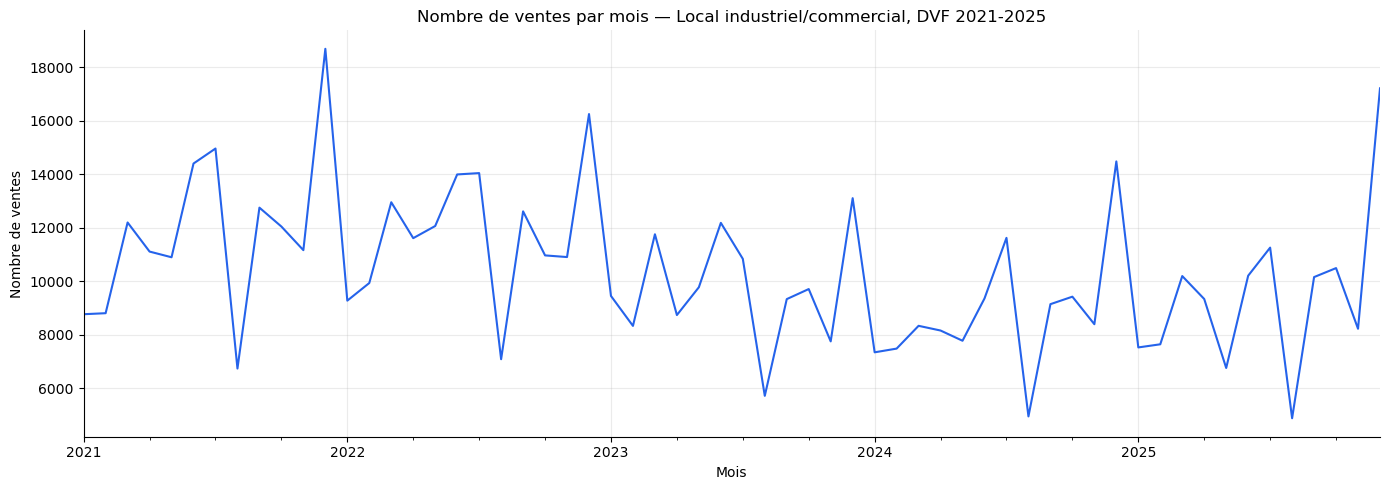

In [10]:
monthly_commercial = None

for chunk in pd.read_csv(CSV_PATH, chunksize=CHUNK_SIZE, low_memory=False,
                          usecols=["type_local", "nature_mutation", "date_mutation"], parse_dates=["date_mutation"]):
    sub = chunk[(chunk["type_local"] == TYPE_LOCAL_CIBLE) & (chunk["nature_mutation"] == "Vente")]
    counts = sub["date_mutation"].dt.to_period("M").value_counts()
    monthly_commercial = counts if monthly_commercial is None else monthly_commercial.add(counts, fill_value=0)

monthly_commercial = monthly_commercial.sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
monthly_commercial.plot(ax=ax, color=COLORS["bleu_primaire"])
ax.set_title("Nombre de ventes par mois — Local industriel/commercial, DVF 2021-2025")
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre de ventes")
plt.tight_layout()
plt.show()

### Interprétation — tendance temporelle

**Résultat obtenu** : contrairement au résidentiel, la courbe ne montre **pas** de tendance
pluriannuelle nette liée aux taux d'intérêt. Le signal dominant est une **forte saisonnalité
annuelle** :
- Un pic marqué en fin d'année (novembre-décembre) chaque année, particulièrement extrême en 2021
  (~18 700 ventes) et 2022 (~16 300)
- Un creux estival récurrent (généralement autour du mois d'août), avec des points bas à ~4 900-5 800
  ventes en 2023/2024
- Un niveau de base qui baisse légèrement de 2021-2022 vers 2023-2024 (bande 9-19K en 2021 contre
  bande 5-14K en 2023-2024), avant une reprise nette en toute fin de série (~17 200 sur le dernier
  mois observé)

**Interprétation** : le marché commercial/industriel semble beaucoup plus rythmé par la **clôture
d'exercice fiscal des entreprises et investisseurs** (bouclage de transactions avant la fin d'année
civile) que par les taux de crédit immobilier des particuliers — cohérent avec le fait que ces
transactions impliquent surtout des acheteurs professionnels (financement différent des ménages).
Ça infirme l'hypothèse de départ ("même dynamique remontée des taux → ralentissement") : la dynamique
est structurellement différente de celle observée sur le résidentiel, pas juste une version
atténuée.

---


### Exploration terminée (sections 1-8)

Toutes les sections ont été exécutées sur les données réelles (650 255 lignes, périmètre
`Local industriel. commercial ou assimilé`) :

- [x] Volumétrie confirmée : 650 255 lignes, 3.19% du brut — conforme à l'estimation du notebook 01
- [x] Valeurs manquantes qualifiées — `surface_reelle_bati` moins fiable qu'en résidentiel (5.54%
      manquant), `nombre_pieces_principales` bien renseigné mais peu pertinent sémantiquement
- [x] `nature_mutation` : Vente + VEFA = 98.95% du périmètre, VEFA proportionnellement plus fréquent
      qu'en résidentiel (3.43% vs 1.92%)
- [x] `nombre_lots` écarté comme signal de vente en bloc — hypothèse de départ infirmée (88.75% des
      transactions ont ≤1 lot)
- [x] `valeur_fonciere` : distribution extrêmement étalée, max observé à 14.15 milliards € — seuils
      résidentiels définitivement non transposables
- [x] `surface_reelle_bati` : médiane comparable au résidentiel (81 m²) mais queue extrême (max
      646 230 m²)
- [x] Tendance temporelle : saisonnalité annuelle forte (pic fin d'année, creux estival), pas de lien
      visible avec les taux d'intérêt — dynamique différente du résidentiel

### Suite du travail

L'investigation approfondie (valeurs extrêmes, dédoublonnage, règle "vente en bloc" adaptée, seuil de
plausibilité de prix) est menée dans **`04_regles_nettoyage_commercial.ipynb`**, en miroir de
`02_regles_nettoyage_dvf.ipynb` pour le résidentiel — ce notebook-ci reste une exploration de premier
niveau, comme `01_exploration_dvf.ipynb`.